# Causal AI Fairness — Example 

In this notebook, we reproduce **Example** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect the distributions of the effects
- Report from the LLM given the results

## 1. Imports and repository setup

The cell below makes the notebook robust whether it is launched from the repository root or from the notebooks directory.

In [1]:
from pathlib import Path
import sys
import json
import os
import pandas as pd
from pgmpy.estimators import BayesianEstimator
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv(override=True)  # loads OPENAI_API_KEY from .env

if os.getenv("OPENAI_API_KEY") is None:
    raise RuntimeError("OPENAI_API_KEY not found. ")

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.visualisation.graph import visualize_sfm
from src.llm import prepare_llm_payload_general, payload_to_json, summarize_with_llm_combined
REPO_ROOT

/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness')

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [2]:
data_path = REPO_ROOT / "data" / "processed" / "student_mat.csv"
df = pd.read_csv(data_path)

selected_columns = [
    "S2_sex",
    "T_grade",
    "studytime",
]

df[selected_columns].head()


,S2_sex,T_grade,studytime
0,F,0,2
1,F,0,2
2,F,1,2
3,F,1,3
4,F,1,2


In [3]:
df["S2_sex"].dtype
df["S2_sex"] = df["S2_sex"].astype("category")
df["T_grade"].dtype
df["T_grade"] = df["T_grade"].astype("category")
df["studytime"].dtype


dtype('int64')

In [4]:
df[selected_columns].nunique().rename("cardinality")

S2_sex       2
T_grade      2
studytime    4
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [5]:
private_attr = "S2_sex"
outcome_attr = "T_grade"
confounders = []
mediators = ["studytime"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_sex', 'T_grade'), ('S2_sex', 'studytime'), ('studytime', 'T_grade')]

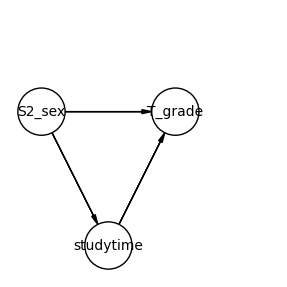

In [49]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [50]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()


2026-03-10 22:41:58.818 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_sex': 'C', 'T_grade': 'C', 'studytime': 'N'}


In [51]:
variable_metadata = pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)
variable_metadata

S2_sex             [F, M]
T_grade            [0, 1]
studytime    [1, 2, 3, 4]
Name: states, dtype: object

## 5. Compute core fairness effects

We evaluate the probability of the `1` grade outcome when comparing `Female` to `Male`.

In [ ]:
target = (outcome_attr, 1)
x0 = "F"
x1 = "M"

results = pd.Series(
    {
        "TV": TV(bn, target, private_attr, x0, x1),
        "TE": TE(bn, target, private_attr, x0, x1),
        "SE(x0)": SE(bn, target, private_attr, x0),
        "SE(x1)": SE(bn, target, private_attr, x1),
        "NDE": DE(bn, target, private_attr, x0, x1),
        "NIE": IE(bn, target, private_attr, x1, x0),
        "NIE_f": IE(bn, target, private_attr, x0, x1),
    },
    name="effect",
)

results.round(4)

2026-03-10 22:41:58.832 | DEBUG    | src.effects:total_variation:247 - Computing total variation for target=('T_grade', 1), private_baseline=F, private_mod=M
2026-03-10 22:41:58.833 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_grade', 1), private_value=F
2026-03-10 22:41:58.834 | DEBUG    | src.effects:spurious_effect:194 - Computing spurious effect for target=('T_grade', 1), private_value=M


TV        0.0626
TE        0.0626
SE(x0)    0.0000
SE(x1)    0.0000
NDE       0.1119
NIE       0.0492
NIE_f    -0.0024
Name: effect, dtype: float64

## 6. Inspect full effect distributions

The library can return the full state-wise effect distribution for a target, not just a single state. That is useful when the target has multiple categories or when you want to define your own utility over outcomes.

In [53]:
target_states = bn.get_cpds(outcome_attr).state_names[outcome_attr]
te_distribution = effect_distribution(TE, bn, outcome_attr, private_attr, x0, x1)

pd.DataFrame({"state": target_states, "TE": te_distribution}).round(4)

,state,TE
0,0,-0.0626
1,1,0.0626


## 7. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In [56]:
decomposition_check = pd.Series(
    {
        "TV": results["TV"],
        "TE + (SE(Fx1) - SE(x0))": results["TE"]
        + (results["SE(x1)"] - results["SE(x0)"]),
        "difference": results["TV"]
        - (results["TE"] + (results["SE(x1)"] - results["SE(x0)"])),
    },
)

decomposition_check.round(10)

TV                         0.062639
TE + (SE(Fx1) - SE(x0))    0.062639
difference                 0.000000
dtype: float64

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.

In [57]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"],
        "NDE - NIE":  (results["NDE"] - results["NIE"]),
    },
)

decomposition_check_TE.round(10)

TE           0.062639
NDE - NIE    0.062639
dtype: float64

## 8. LLM report 

In [58]:
client = OpenAI()

In [59]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [60]:
payload = prepare_llm_payload_general(
    dataset_name="Student mat",
    X=private_attr,
    Y=outcome_attr,
    W=["studytime"],
    Z=[],
    x0=x0,
    x1=x1,
    y_target=1,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    graph_edges=sorted(sfm.edges()),
    checks={
        "tv_decomposition": decomposition_check.round(10).to_dict(),
        "te_decomposition": decomposition_check_TE.round(10).to_dict(),
    },
)

In [61]:
payload_json = payload_to_json(payload)

In [62]:
text, latex_doc,token_usage = summarize_with_llm_combined(payload_json, client)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


In [63]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}

\section*{Title: "Fairness Decomposition Report"}

\subsection*{Overview of the Fairness Analysis}
This analysis decomposes the difference in the binary outcome T\_grade (values 0/1) between groups defined by S2\_sex, comparing $X=\mathrm{F}$ (x0) versus $X=\mathrm{M}$ (x1). The decomposition partitions the total variation in the probability of $T\_grade=1$ into direct, indirect (mediated by studytime), and spurious components. The provided results quantify total variation (TV), total effect (TE), natural direct effect (NDE), natural indirect effect (NIE), and spurious effects for each group.

\subsection*{Decomposition of Effects}
\begin{itemize}
\item \textbf{Total variation (TV):} $0.0626$. Interpretation: The overall difference in probability of $T\_grade=1$ between M and F is about $0.0626$ (M higher). This is the observed disparity to be explained.
\item \textbf{Total effect

In [64]:
token_usage

ResponseUsage(input_tokens=2195, input_tokens_details=InputTokensDetails(cached_tokens=0), output_tokens=3140, output_tokens_details=OutputTokensDetails(reasoning_tokens=1536), total_tokens=5335)